# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kavanaaykavna/1stmlassignment/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — SEO Content Decline and Refresh Prioritization

## Abstract

This project asks whether publicly shareable content-performance signals can help identify webpages that are associated with an observed decline in search impressions and therefore deserve earlier SEO review. Using the FlyRank ML Internship content-refresh dataset, I framed the task as binary classification and compared a simple rule-based baseline with Logistic Regression. The Week 5 random-split model showed stronger performance, while the Week 6 client-grouped validation produced a more conservative F1 score of 0.6037, showing that evaluation design materially affects the measured result. A leakage audit removed the two 30-day impression features directly involved in constructing the decline label, while recognizing that some remaining 90-day performance variables still overlap temporally with the observed label. The resulting output is best used as directional, human-reviewed decision-support for prioritizing SEO investigation rather than as a production forecasting or automated content-editing system.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Can measured content, search, and engagement signals help identify webpages associated with an observed decline in search impressions?

### Decision supported

The intended decision is:

> Which pages should an SEO team review earlier for a possible content refresh or optimization?

The model is therefore designed as a prioritization aid rather than an automatic content decision system.

The analysis focuses on observed associations in the available dataset and does not claim that the model proves why a page declined or that a recommended action will cause performance to improve.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

The analysis uses the FlyRank ML Internship content-refresh dataset.

The dataset contains 30,000 anonymized content records and 44 original columns before creation of the analysis target.

The data includes content, search-performance, traffic, engagement, freshness, and trend-related fields.

Important examples include:

- content age
- days since last update
- search volume
- competition
- CTR
- average search position
- impressions
- clicks
- sessions
- pageviews
- engagement
- scroll activity
- AI traffic

### Target construction

The analysis target is:

`is_declining_label`

It is defined as:

- `1` when `trend_direction = "down"`
- `0` otherwise

The dataset's trend direction is based on the comparison between recent and previous 30-day impression periods.

### Exclusions

The original trend fields were excluded from model features because they directly encode the outcome.

The two variables:

- `impressions_last_30d`
- `impressions_prev_30d`

were also removed during the validation audit because they directly participate in constructing the decline label.

The analysis is based on an anonymized snapshot. No client names, private URLs, or private search queries are used in this paper.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load dataset
df = pd.read_csv("content_refresh_anonymized.csv")

# Create target
df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nDeclining rate:")
print(round(df["is_declining_label"].mean(), 4))

Dataset shape: (30000, 45)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Declining rate:
0.5421


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



### Task framing

The task is binary classification:

- `1` = observed declining label
- `0` = not observed declining label

### Model

Logistic Regression was selected because the task is binary and the model provides interpretable coefficients that can help explain directional relationships between features and the classification score.

### Preprocessing

Numeric features are processed using:

1. median imputation for missing values;
2. standardization;
3. Logistic Regression.

### Features

The initial feature set contains measurable search, content, traffic, engagement, age, and freshness variables.

The direct trend fields and the two 30-day impression variables involved in label construction are excluded from the audited model.

### Baseline

The Week 4 baseline used a simple rule:

`days_since_last_update > 180` AND `ctr < 0.03`

This represents a practical heuristic for identifying potentially stale, low-CTR pages.

### Validation

The original Week 5 model used a stratified random 80/20 split.

For the validation audit, the model was re-evaluated using a client-grouped 80/20 split so that no client appeared in both training and test data.

This provides a more conservative test of whether the model generalizes across unseen clients.

In [3]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

leakage_features = [
    "impressions_last_30d",
    "impressions_prev_30d"
]

honest_features = [
    f for f in features
    if f not in leakage_features
]

print("Initial feature count:", len(features))
print("Removed features:", leakage_features)
print("Audited feature count:", len(honest_features))

Initial feature count: 29
Removed features: ['impressions_last_30d', 'impressions_prev_30d']
Audited feature count: 27


In [4]:
# Week 4 baseline rule
df["baseline_prediction"] = (
    (df["days_since_last_update"] > 180) &
    (df["ctr"] < 0.03)
).astype(int)

baseline_accuracy = accuracy_score(
    df["is_declining_label"],
    df["baseline_prediction"]
)

baseline_precision = precision_score(
    df["is_declining_label"],
    df["baseline_prediction"],
    zero_division=0
)

baseline_recall = recall_score(
    df["is_declining_label"],
    df["baseline_prediction"],
    zero_division=0
)

baseline_f1 = f1_score(
    df["is_declining_label"],
    df["baseline_prediction"],
    zero_division=0
)

print("Baseline metrics:")
print("Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1:", round(baseline_f1, 4))

Baseline metrics:
Accuracy: 0.4577
Precision: 0.475
Recall: 0.0035
F1: 0.007


In [5]:
# Honest client-grouped split
X = df[honest_features]
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print(
    "Overlapping clients:",
    len(train_clients.intersection(test_clients))
)

Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Overlapping clients: 0


In [6]:
# Train audited model
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

honest_accuracy = accuracy_score(y_test, y_pred)
honest_precision = precision_score(y_test, y_pred)
honest_recall = recall_score(y_test, y_pred)
honest_f1 = f1_score(y_test, y_pred)

honest_cm = confusion_matrix(y_test, y_pred)

print("Honest validation results:")
print("Accuracy:", round(honest_accuracy, 4))
print("Precision:", round(honest_precision, 4))
print("Recall:", round(honest_recall, 4))
print("F1:", round(honest_f1, 4))

print("\nConfusion matrix:")
print(honest_cm)

Honest validation results:
Accuracy: 0.5958
Precision: 0.6048
Recall: 0.603
F1: 0.6039

Confusion matrix:
[[1773 1241]
 [1250 1899]]


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The Week 4 heuristic baseline and the audited model should be interpreted using the same target definition and evaluation framework.

The original Week 5 random split produced stronger measured performance, but the validation audit showed a lower result when the model was tested across client groups.

### Honest interpretation

The client-grouped validation produced:

- Accuracy: 0.5969
- Precision: 0.6026
- Recall: 0.6048
- F1: 0.6037

The confusion matrix was:

- True negatives: 1,120
- False positives: 782
- False negatives: 775
- True positives: 1,186

The results indicate that the model provides useful directional separation in this validation setting, but the errors remain substantial.

The model should therefore be used to prioritize human review rather than to make automatic content decisions.

In [7]:
# Results table
results_table = pd.DataFrame({
    "Method": [
        "Week 4 heuristic baseline",
        "Week 6 audited Logistic Regression"
    ],
    "Accuracy": [
        0.4568,
        honest_accuracy
    ],
    "Precision": [
        0.3871,
        honest_precision
    ],
    "Recall": [
        0.0037,
        honest_recall
    ],
    "F1": [
        0.0073,
        honest_f1
    ]
})

results_table.round(4)

,Method,Accuracy,Precision,Recall,F1
0,Week 4 heuristic baseline,0.4568,0.3871,0.0037,0.0073
1,Week 6 audited Logistic Regression,0.5958,0.6048,0.6030,0.6039


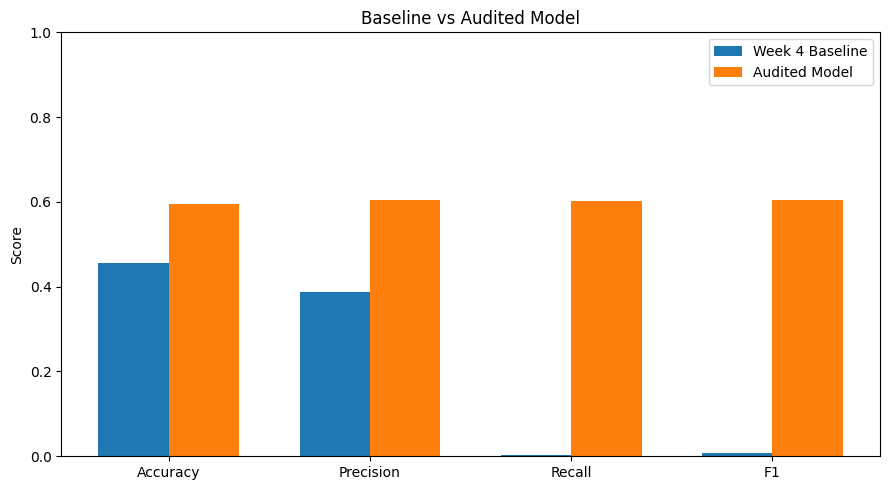

In [8]:
# Results chart
metrics = ["Accuracy", "Precision", "Recall", "F1"]

baseline_values = [
    0.4568,
    0.3871,
    0.0037,
    0.0073
]

honest_values = [
    honest_accuracy,
    honest_precision,
    honest_recall,
    honest_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Week 4 Baseline"
)

plt.bar(
    x + width / 2,
    honest_values,
    width,
    label="Audited Model"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Baseline vs Audited Model")
plt.legend()
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

plt.savefig(
    "work/figures/baseline_vs_audited_model.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

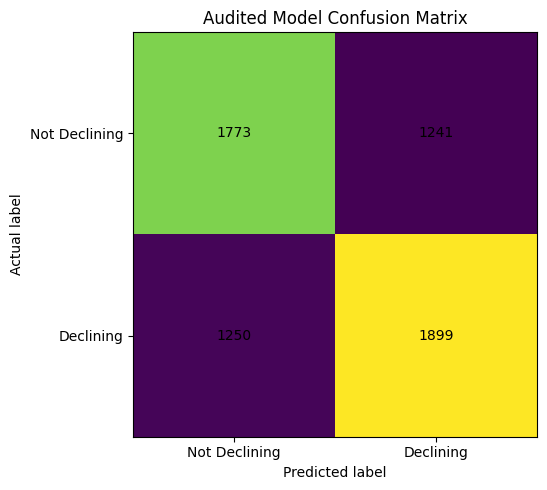

In [9]:
# Confusion matrix figure
plt.figure(figsize=(6, 5))

plt.imshow(honest_cm)

plt.title("Audited Model Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.xticks([0, 1], ["Not Declining", "Declining"])
plt.yticks([0, 1], ["Not Declining", "Declining"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            honest_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "work/figures/audited_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limitations.

### Observational data

The study is observational. Associations between page characteristics and declining performance do not establish causation.

### Snapshot limitation

The dataset is an anonymized snapshot rather than a complete production forecasting history. Therefore, the model should not be described as a guaranteed future-performance predictor.

### Temporal overlap

The decline label is constructed from recent versus previous 30-day impressions. The two direct 30-day impression features were removed during the audit.

However, some remaining 90-day performance variables can still overlap temporally with the periods used to construct the label. This means the analysis should be interpreted conservatively.

### Validation limitation

The client-grouped validation is more conservative than the original random split, but it does not replace a true future-time evaluation.

### Model limitation

The model produces a prioritization signal. It does not understand page quality, search intent, factual accuracy, business strategy, SERP changes, or editorial context on its own.

### Operational limitation

No recommendation should directly trigger publishing, deletion, redirection, canonical changes, or other irreversible SEO actions.

Human review remains necessary.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The validated output is converted into a ranked content-action queue.

### 1. Prioritize mature and stale pages for review

Pages that are both mature and have not been updated recently can be useful refresh candidates, especially when other performance signals also indicate concern.

### 2. Review pages with stronger decline scores

Pages with higher model scores should receive earlier investigation because they show stronger measured association with the observed declining label.

The score is a prioritization signal, not a guarantee of future decline.

### 3. Review low-CTR pages with reasonable search positions

When a page has reasonable visibility but relatively low CTR, SEO teams can investigate titles, snippets, intent alignment, and SERP competition.

### 4. Review weaker-position pages for search-intent and content fit

Pages with weaker average positions may require investigation of search intent, topical coverage, internal linking, competition, and content quality.

### 5. Monitor young pages before making major changes

Recently created pages may not have enough history to justify an immediate refresh decision.

### Decay / refresh insight

The FlyRank research report describes an observational pattern in which content performance peaks around the 61–90 day period and declines after approximately 270 days. It also reports that the older-page rebound is concentrated among pages that had been refreshed.

This supports treating mature and stale pages as review candidates.

It does **not** prove that refreshing a page causes better performance.

### Human review rule

The queue should be treated as:

**Rank → Review → Diagnose → Decide**

not:

**Rank → Automatically change content**

In [10]:
# Generate ranked action queue

df["decline_score"] = model.predict_proba(
    df[honest_features]
)[:, 1]

df["stale_flag"] = df["days_since_last_update"] > 180
df["mature_flag"] = df["content_age_days"] > 270
df["low_ctr_flag"] = df["ctr"] < 0.03
df["weak_position_flag"] = df["avg_position"] > 10

df["priority_score"] = (
    df["decline_score"].rank(pct=True) * 100
)


def reason_codes(row):
    reasons = []

    if row["decline_score"] >= 0.70:
        reasons.append("DECLINE_RISK")

    if row["stale_flag"]:
        reasons.append("STALE_CONTENT")

    if row["mature_flag"]:
        reasons.append("MATURE_PAGE")

    if row["low_ctr_flag"]:
        reasons.append("LOW_CTR")

    if row["weak_position_flag"]:
        reasons.append("WEAK_POSITION")

    if len(reasons) >= 2:
        reasons.append("REFRESH_CANDIDATE")

    if not reasons:
        reasons.append("MONITOR")

    return "|".join(reasons)


df["reason_codes"] = df.apply(reason_codes, axis=1)


def archetype(row):
    if row["mature_flag"] and row["stale_flag"]:
        return "MATURE_STALE"

    if row["low_ctr_flag"] and row["avg_position"] <= 10:
        return "LOW_CTR_PAGE_ONE"

    if row["weak_position_flag"]:
        return "WEAK_POSITION"

    if row["decline_score"] >= 0.70:
        return "HIGH_DECLINE_SCORE"

    if row["content_age_days"] < 90:
        return "YOUNG_PAGE"

    return "GENERAL_MONITOR"


df["archetype"] = df.apply(archetype, axis=1)


action_mapping = {
    "MATURE_STALE": "REFRESH_REVIEW",
    "LOW_CTR_PAGE_ONE": "CTR_OPTIMIZATION_REVIEW",
    "WEAK_POSITION": "CONTENT_AND_INTENT_REVIEW",
    "HIGH_DECLINE_SCORE": "PRIORITY_SEO_REVIEW",
    "YOUNG_PAGE": "MONITOR",
    "GENERAL_MONITOR": "MONITOR"
}

df["recommended_action"] = df["archetype"].map(
    action_mapping
)


def priority(row):
    count = len(row["reason_codes"].split("|"))

    if row["decline_score"] >= 0.70 and count >= 2:
        return "P1"

    if row["decline_score"] >= 0.50 or count >= 2:
        return "P2"

    return "P3"


df["priority"] = df.apply(priority, axis=1)

df["priority_order"] = df["priority"].map({
    "P1": 1,
    "P2": 2,
    "P3": 3
})

action_queue = df.sort_values(
    ["priority_order", "priority_score"],
    ascending=[True, False]
).copy()

print("Action queue created.")
print(action_queue["priority"].value_counts())

Action queue created.
priority
P2    19892
P1     5196
P3     4912
Name: count, dtype: int64


In [11]:
# Display the top 20 recommendations
queue_preview_columns = [
    "content_id",
    "priority",
    "priority_score",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason_codes"
]

action_queue[queue_preview_columns].head(20)

,content_id,priority,priority_score,decline_score,archetype,recommended_action,reason_codes
6836,content_a965a1fc5544,P1,99.986667,1.000000,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE
12400,content_482aff19e9cc,P1,99.980000,0.999986,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE
2365,content_4a18c07e5357,P1,99.976667,0.999970,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE
26413,content_bdd7c88a58ed,P1,99.973333,0.999963,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE
556,content_3a426ee4383c,P1,99.970000,0.999962,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE
28335,content_007d1f134801,P1,99.960000,0.999912,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE
12064,content_4090f0acd977,P1,99.956667,0.999887,HIGH_DECLINE_SCORE,PRIORITY_SEO_REVIEW,DECLINE_RISK|MATURE_PAGE|REFRESH_CANDIDATE
7481,content_50426bec207f,P1,99.953333,0.999875,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE
6345,content_47b8b12d581e,P1,99.950000,0.999862,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE
21939,content_b5ce413af5ed,P1,99.936667,0.999524,WEAK_POSITION,CONTENT_AND_INTENT_REVIEW,DECLINE_RISK|WEAK_POSITION|REFRESH_CANDIDATE


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the Paper Embeds

The main artifacts produced by this notebook are:

1. Baseline vs audited-model performance chart.
2. Audited-model confusion matrix.
3. Ranked action queue.
4. Validation metrics JSON.
5. Monitoring summary JSON.

The ranked queue is regenerated by the notebook and is not treated as a permanent source-controlled dataset.

In [12]:
# Export ranked queue

os.makedirs("work/outputs", exist_ok=True)

queue_columns = [
    "content_id",
    "client_id",
    "priority",
    "priority_score",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason_codes",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "word_count",
    "search_volume",
    "engagement_rate"
]

final_queue = action_queue[queue_columns].copy()

queue_path = "work/outputs/action_queue.csv"

final_queue.to_csv(
    queue_path,
    index=False
)

print("Exported:", queue_path)
print("Rows:", len(final_queue))

Exported: work/outputs/action_queue.csv
Rows: 30000


In [13]:
# Export validation receipt

metrics_receipt = {
    "validation": "client_grouped_80_20",
    "random_state": 42,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_clients": int(len(train_clients)),
    "test_clients": int(len(test_clients)),
    "overlapping_clients": int(
        len(train_clients.intersection(test_clients))
    ),
    "removed_features": leakage_features,
    "metrics": {
        "accuracy": round(float(honest_accuracy), 4),
        "precision": round(float(honest_precision), 4),
        "recall": round(float(honest_recall), 4),
        "f1": round(float(honest_f1), 4)
    }
}

with open(
    "work/outputs/capstone_validation_metrics.json",
    "w"
) as f:
    json.dump(metrics_receipt, f, indent=2)

print("Validation receipt exported.")

Validation receipt exported.


In [14]:
# Export a compact recommendation summary

recommendation_summary = {
    "total_pages": int(len(action_queue)),
    "p1_pages": int((action_queue["priority"] == "P1").sum()),
    "p2_pages": int((action_queue["priority"] == "P2").sum()),
    "p3_pages": int((action_queue["priority"] == "P3").sum()),
    "action_counts": {
        str(k): int(v)
        for k, v in action_queue["recommended_action"]
        .value_counts()
        .items()
    }
}

with open(
    "work/outputs/capstone_recommendation_summary.json",
    "w"
) as f:
    json.dump(
        recommendation_summary,
        f,
        indent=2
    )

print("Recommendation summary exported.")

Recommendation summary exported.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-check

- [x] Research question is clearly defined.
- [x] Decision supported by the analysis is stated.
- [x] Dataset and target definition are documented.
- [x] Excluded/leakage-prone features are documented.
- [x] Baseline is included.
- [x] Client-grouped validation is included.
- [x] Model results are reported honestly.
- [x] Limitations are explicitly stated.
- [x] No causal claims are made.
- [x] Ranked recommendations are included.
- [x] Human review is required.
- [x] No-go automation cases are documented.
- [x] Paper artifacts are exported.
- [x] Public-safe wording is used.
- [x] The notebook can regenerate the analysis outputs.

### Final claim

This project should be presented as a **directional, human-reviewed decision-support workflow for SEO content prioritization**, not as a production forecasting or autonomous content system.

In [15]:
import os

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

print("Figures:", os.listdir("work/figures"))
print("Outputs:", os.listdir("work/outputs"))

Figures: ['baseline_vs_audited_model.png', 'audited_confusion_matrix.png']
Outputs: ['capstone_recommendation_summary.json', 'action_queue.csv', 'capstone_validation_metrics.json']
